In [1]:
# import os for traversing csv files
import os

# import tqdm for visualizing how long some loop will take
from tqdm import tqdm

# import pandas and numpy for math and data processing
import pandas as pd
import numpy as np

# import matplotlib and seaborn for plotting and visualizations
from matplotlib import pyplot as plt
import seaborn

# import gradient-boosted decision tree library - XGBoost
import xgboost as xgb

# import loss functions
from sklearn.metrics import brier_score_loss, mean_absolute_error

# import spline interpolation
from scipy.interpolate import UnivariateSpline

# options to suppress irrelevant errors and comprehensive display for pandas
pd.options.mode.chained_assignment = None 
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

In [2]:
# Helper function: given the path of a csv file, returns a list of the columns
def col_list(csv_file):
    df = pd.read_csv(f'data/{csv_file}')
    return df.columns.tolist()

In [3]:
# display all the csv files, along with the columns of data they contain
csv_list = os.listdir('data')
csv_list.remove(".gitattributes")
for i in range(len(csv_list)):
    csv = csv_list[i]
    print(f"{i + 1}: {csv} - Columns: {col_list(csv)}")

1: MNCAATourneyDetailedResults.csv - Columns: ['Season', 'DayNum', 'WTeamID', 'WScore', 'LTeamID', 'LScore', 'WLoc', 'NumOT', 'WFGM', 'WFGA', 'WFGM3', 'WFGA3', 'WFTM', 'WFTA', 'WOR', 'WDR', 'WAst', 'WTO', 'WStl', 'WBlk', 'WPF', 'LFGM', 'LFGA', 'LFGM3', 'LFGA3', 'LFTM', 'LFTA', 'LOR', 'LDR', 'LAst', 'LTO', 'LStl', 'LBlk', 'LPF']
2: WNCAATourneySlots.csv - Columns: ['Season', 'Slot', 'StrongSeed', 'WeakSeed']
3: MSeasons.csv - Columns: ['Season', 'DayZero', 'RegionW', 'RegionX', 'RegionY', 'RegionZ']
4: WTeams.csv - Columns: ['TeamID', 'TeamName']
5: MRegularSeasonDetailedResults.csv - Columns: ['Season', 'DayNum', 'WTeamID', 'WScore', 'LTeamID', 'LScore', 'WLoc', 'NumOT', 'WFGM', 'WFGA', 'WFGM3', 'WFGA3', 'WFTM', 'WFTA', 'WOR', 'WDR', 'WAst', 'WTO', 'WStl', 'WBlk', 'WPF', 'LFGM', 'LFGA', 'LFGM3', 'LFGA3', 'LFTM', 'LFTA', 'LOR', 'LDR', 'LAst', 'LTO', 'LStl', 'LBlk', 'LPF']
6: WNCAATourneyDetailedResults.csv - Columns: ['Season', 'DayNum', 'WTeamID', 'WScore', 'LTeamID', 'LScore', 'WLoc',

In [5]:
# Store and display the men's data files

womens_data = [csv for csv in csv_list if csv[0] == 'W']

print("WOMENS INFO:\n--------------------------")

for wf in womens_data:
    print(f"{wf[:-4]}: {col_list(wf)}")

WOMENS INFO:
--------------------------
WNCAATourneySlots: ['Season', 'Slot', 'StrongSeed', 'WeakSeed']
WTeams: ['TeamID', 'TeamName']
WNCAATourneyDetailedResults: ['Season', 'DayNum', 'WTeamID', 'WScore', 'LTeamID', 'LScore', 'WLoc', 'NumOT', 'WFGM', 'WFGA', 'WFGM3', 'WFGA3', 'WFTM', 'WFTA', 'WOR', 'WDR', 'WAst', 'WTO', 'WStl', 'WBlk', 'WPF', 'LFGM', 'LFGA', 'LFGM3', 'LFGA3', 'LFTM', 'LFTA', 'LOR', 'LDR', 'LAst', 'LTO', 'LStl', 'LBlk', 'LPF']
WSeasons: ['Season', 'DayZero', 'RegionW', 'RegionX', 'RegionY', 'RegionZ']
WRegularSeasonDetailedResults: ['Season', 'DayNum', 'WTeamID', 'WScore', 'LTeamID', 'LScore', 'WLoc', 'NumOT', 'WFGM', 'WFGA', 'WFGM3', 'WFGA3', 'WFTM', 'WFTA', 'WOR', 'WDR', 'WAst', 'WTO', 'WStl', 'WBlk', 'WPF', 'LFGM', 'LFGA', 'LFGM3', 'LFGA3', 'LFTM', 'LFTA', 'LOR', 'LDR', 'LAst', 'LTO', 'LStl', 'LBlk', 'LPF']
WNCAATourneySeeds: ['Season', 'Seed', 'TeamID']
WConferenceTourneyGames: ['Season', 'ConfAbbrev', 'DayNum', 'WTeamID', 'LTeamID']
WTeamConferences: ['Season', 'T

In [8]:
# Load the men's data and save as dataframes
W_regular_season_results = pd.read_csv("data/WRegularSeasonDetailedResults.csv")
W_tourney_results = pd.read_csv("data/WNCAATourneyDetailedResults.csv")
W_seeds = pd.read_csv("data/WNCAATourneySeeds.csv")
W_teams = pd.read_csv("data/WTeams.csv")

In [10]:
W_tourney_results

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,WFGM3,WFGA3,WFTM,WFTA,WOR,WDR,WAst,WTO,WStl,WBlk,WPF,LFGM,LFGA,LFGM3,LFGA3,LFTM,LFTA,LOR,LDR,LAst,LTO,LStl,LBlk,LPF
0,2010,138,3124,69,3201,55,N,0,28,57,1,5,12,19,13,24,22,12,6,2,12,21,61,10,34,3,5,17,19,12,18,4,1,18
1,2010,138,3173,67,3395,66,N,0,23,59,9,26,12,19,13,34,13,16,3,10,14,22,73,8,27,14,15,18,26,8,8,8,6,22
2,2010,138,3181,72,3214,37,H,0,26,57,4,13,16,22,13,34,15,11,10,7,11,15,56,4,15,3,8,10,21,4,16,6,4,20
3,2010,138,3199,75,3256,61,H,0,25,63,3,15,22,26,20,27,13,17,8,3,21,21,62,2,20,17,22,16,21,13,16,5,4,24
4,2010,138,3207,62,3265,42,N,0,24,68,8,25,6,8,20,29,16,8,5,5,18,13,60,5,26,11,17,16,22,9,10,3,4,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
956,2025,147,3163,78,3425,64,N,0,27,60,10,22,14,17,3,25,16,12,10,2,17,19,58,3,13,23,26,9,26,7,15,8,2,18
957,2025,147,3400,58,3395,47,N,0,24,61,2,3,8,11,8,21,14,7,9,6,20,12,45,4,20,19,21,9,21,8,16,1,3,14
958,2025,151,3163,85,3417,51,N,0,33,60,7,16,12,17,4,23,17,7,13,2,16,20,52,4,16,7,8,6,20,11,18,5,2,12
959,2025,151,3376,74,3400,57,N,0,29,57,7,11,9,12,8,22,17,13,7,5,15,22,56,4,10,9,12,8,18,10,14,6,5,17


In [14]:
# Only consider recent data by setting a start season
season = 2010
W_regular_season_results = W_regular_season_results.loc[W_regular_season_results["Season"] >= season]
W_tourney_results = W_tourney_results.loc[W_tourney_results["Season"] >= season]
W_seeds = W_seeds.loc[W_seeds["Season"] >= season]

In [15]:
# Display the women's regular season results - every individual game
W_regular_season_results

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,WFGM3,WFGA3,WFTM,WFTA,WOR,WDR,WAst,WTO,WStl,WBlk,WPF,LFGM,LFGA,LFGM3,LFGA3,LFTM,LFTA,LOR,LDR,LAst,LTO,LStl,LBlk,LPF
0,2010,11,3103,63,3237,49,H,0,23,54,5,9,12,19,10,26,14,18,7,0,15,20,54,3,13,6,10,11,27,11,23,7,6,19
1,2010,11,3104,73,3399,68,N,0,26,62,5,12,16,28,16,31,15,20,5,2,25,25,63,4,21,14,27,14,26,7,20,4,2,27
2,2010,11,3110,71,3224,59,A,0,29,62,6,15,7,12,14,23,18,13,6,2,17,19,58,2,14,19,23,17,23,8,15,6,0,15
3,2010,11,3111,63,3267,58,A,0,27,52,4,11,5,9,6,40,14,27,5,10,18,18,74,6,26,16,25,22,22,15,11,14,5,14
4,2010,11,3119,74,3447,70,H,1,30,74,7,20,7,11,14,33,18,11,5,3,18,25,74,9,17,11,21,21,32,12,14,4,2,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87182,2026,131,3471,60,3218,48,N,0,25,69,3,16,7,8,8,27,13,7,11,1,9,18,48,4,16,8,8,2,31,9,17,3,6,15
87183,2026,132,3158,68,3220,56,N,0,23,61,9,27,13,21,16,26,12,9,5,1,12,23,58,7,21,3,5,9,25,10,13,2,4,17
87184,2026,132,3192,79,3254,57,H,0,31,60,10,19,7,11,9,32,15,10,4,1,18,19,55,7,20,12,14,5,19,2,11,5,4,15
87185,2026,132,3221,77,3250,70,H,0,31,60,5,17,10,12,13,23,16,12,3,4,10,26,55,9,24,9,12,8,17,17,11,6,2,12


In [16]:
# Examine the seeds DataFrame
W_seeds

,Season,Seed,TeamID
768,2010,W01,3163
769,2010,W02,3326
770,2010,W03,3199
771,2010,W04,3235
772,2010,W05,3438
...,...,...,...
1807,2026,Z12,3211
1808,2026,Z13,3453
1809,2026,Z14,3158
1810,2026,Z15,3239


In [18]:
# helper function to visualize a specific team's season

def W_view_season(team_id, season):

    reg_res = W_regular_season_results.loc[
        (W_regular_season_results["Season"] == season)
        & ((W_regular_season_results["WTeamID"] == team_id) | (W_regular_season_results["LTeamID"] == team_id))]
    tour_res = W_tourney_results.loc[
        (W_tourney_results["Season"] == season)
        & ((W_tourney_results["WTeamID"] == team_id) | (W_tourney_results["LTeamID"] == team_id))
    ]

    reg_res["result"] = np.where(reg_res["WTeamID"] == team_id, "W", "L")
    tour_res["result"] = np.where(tour_res["WTeamID"] == team_id, "W", "L")
    reg_res["type"] = "regular season"
    tour_res["type"] = "tournament"

    summary = pd.concat([reg_res, tour_res])

    return summary[["DayNum", "WScore", "LScore", "type", "result"]]

W_view_season(team_id=3163, season=2024)

,DayNum,WScore,LScore,type,result
70978,2,102,58,regular season,W
71162,6,92,81,regular season,L
71309,10,80,48,regular season,W
71432,13,62,44,regular season,W
71679,18,78,67,regular season,L
71703,19,71,63,regular season,W
72099,27,80,68,regular season,L
72161,30,90,63,regular season,W
72306,34,76,64,regular season,W
72433,40,86,62,regular season,W


In [ ]:
# helper function to get a team's seed based on id and season
def W_get_seed(team_id, season):
    return W_seeds.loc[(W_seeds["Season"] == season) & (W_seeds["TeamID"] == team_id)]

W_get_seed(team_id=3163, season=2024) # UConn was a 3th seed in 2024

,Season,Seed,TeamID
1660,2024,Z03,3163


In [21]:
# helper function to prepare data by normalizing statistics for overtime and duplicate each game from
# both teams' perspectives
def prepare_data(results_df):
    
    # remove WLoc from features - Location - Home (H), Away (A), Neutral (N)
    all_but_WLoc = ["Season", "DayNum", "LTeamID", "LScore", "WTeamID", "WScore", "NumOT",
            "LFGM", "LFGA", "LFGM3", "LFGA3", "LFTM", "LFTA", "LOR", "LDR", "LAst", "LTO", "LStl", "LBlk", "LPF",
            "WFGM", "WFGA", "WFGM3", "WFGA3", "WFTM", "WFTA", "WOR", "WDR", "WAst", "WTO", "WStl", "WBlk", "WPF"]
    
    results_df = results_df[all_but_WLoc]

    # creates a column for OT adjustment factor based on NumOT column
    ot_adjust = (40 + 5 * results_df["NumOT"]) / 40

    # specify stats which need to be adjusted
    cols_adjust = ["LScore", "WScore", 
               "LFGM", "LFGA", "LFGM3", "LFGA3", "LFTM", "LFTA", "LOR", "LDR", "LAst", "LTO", "LStl", "LBlk", "LPF",
               "WFGM", "WFGA", "WFGM3", "WFGA3", "WFTM", "WFTA", "WOR", "WDR", "WAst", "WTO", "WStl", "WBlk", "WPF"]

    # for each column that needs to be adjusted, adjust by corresponding adjustment factor
    for col in cols_adjust:
        results_df[col] = results_df[col] / ot_adjust

    # need to have a copy for each result for each team's persepctive (helpful during aggregation)
    # Use T1 and T2 for column standardization instead of W and L
    results_df_symmetric = results_df.copy()
    results_df.columns = [x.replace("W", "T1_").replace("L", "T2_") for x in list(results_df.columns)]
    results_df_symmetric.columns =  [x.replace("L", "T1_").replace("W", "T2_") for x in list(results_df_symmetric.columns)]

    # combine both perspective results
    combined = pd.concat([results_df, results_df_symmetric]).reset_index(drop = True)

    # add point differential for game
    combined["PointDiff"] = combined["T1_Score"] - combined["T2_Score"]

    # add indicator for win for game
    combined["win"] = (combined["PointDiff"] > 0) * 1

    return combined

W_reg_data = prepare_data(W_regular_season_results)

print("Women's Regular Season Detailed Results:")
print(W_reg_data)

W_tourney_data = prepare_data(W_tourney_results)

print("Women's Tourney Detailed Results:")
print(W_tourney_data)

Women's Regular Season Detailed Results:
        Season  DayNum  T2_TeamID   T2_Score  T1_TeamID   T1_Score  NumOT     T2_FGM     T2_FGA  T2_FGM3    T2_FGA3     T2_FTM     T2_FTA      T2_OR      T2_DR     T2_Ast      T2_TO     T2_Stl    T2_Blk      T2_PF     T1_FGM     T1_FGA   T1_FGM3    T1_FGA3     T1_FTM     T1_FTA      T1_OR      T1_DR  T1_Ast      T1_TO    T1_Stl     T1_Blk  T1_PF  PointDiff  win
0         2010      11       3237  49.000000       3103  63.000000      0  20.000000  54.000000      3.0  13.000000   6.000000  10.000000  11.000000  27.000000  11.000000  23.000000   7.000000  6.000000  19.000000  23.000000  54.000000  5.000000   9.000000  12.000000  19.000000  10.000000  26.000000    14.0  18.000000  7.000000   0.000000   15.0  14.000000    1
1         2010      11       3399  68.000000       3104  73.000000      0  25.000000  63.000000      4.0  21.000000  14.000000  27.000000  14.000000  26.000000   7.000000  20.000000   4.000000  2.000000  27.000000  26.000000  62.00

In [22]:
# Sanity check to ensure that preprocessing has worked successfully - check a specific outcome for symmetry
season = W_reg_data["Season"] == 2025
T1, T2 = 3163, 3166
match1 = (W_reg_data["T1_TeamID"] == T1) & (W_reg_data["T2_TeamID"] == T2)
match2 = (W_reg_data["T1_TeamID"] == T2) & (W_reg_data["T2_TeamID"] == T1)

W_reg_data.loc[season & (match1 | match2)]

,Season,DayNum,T2_TeamID,T2_Score,T1_TeamID,T1_Score,NumOT,T2_FGM,T2_FGA,T2_FGM3,T2_FGA3,T2_FTM,T2_FTA,T2_OR,T2_DR,T2_Ast,T2_TO,T2_Stl,T2_Blk,T2_PF,T1_FGM,T1_FGA,T1_FGM3,T1_FGA3,T1_FTM,T1_FTA,T1_OR,T1_DR,T1_Ast,T1_TO,T1_Stl,T1_Blk,T1_PF,PointDiff,win
79475,2025,82,3166,61.0,3163,72.0,0,24.0,57.0,8.0,24.0,5.0,6.0,4.0,30.0,17.0,16.0,1.0,4.0,15.0,28.0,70.0,4.0,20.0,12.0,13.0,11.0,24.0,19.0,5.0,13.0,5.0,14.0,11.0,1
81015,2025,115,3166,53.0,3163,72.0,0,20.0,58.0,8.0,28.0,5.0,7.0,4.0,25.0,12.0,17.0,7.0,1.0,12.0,30.0,64.0,6.0,17.0,6.0,11.0,11.0,25.0,16.0,11.0,15.0,7.0,12.0,19.0,1
81576,2025,126,3166,50.0,3163,70.0,0,19.0,53.0,6.0,23.0,6.0,6.0,2.0,20.0,10.0,16.0,10.0,0.0,13.0,24.0,54.0,9.0,24.0,13.0,16.0,8.0,25.0,11.0,17.0,13.0,5.0,13.0,20.0,1
166662,2025,82,3163,72.0,3166,61.0,0,28.0,70.0,4.0,20.0,12.0,13.0,11.0,24.0,19.0,5.0,13.0,5.0,14.0,24.0,57.0,8.0,24.0,5.0,6.0,4.0,30.0,17.0,16.0,1.0,4.0,15.0,-11.0,0
168202,2025,115,3163,72.0,3166,53.0,0,30.0,64.0,6.0,17.0,6.0,11.0,11.0,25.0,16.0,11.0,15.0,7.0,12.0,20.0,58.0,8.0,28.0,5.0,7.0,4.0,25.0,12.0,17.0,7.0,1.0,12.0,-19.0,0
168763,2025,126,3163,70.0,3166,50.0,0,24.0,54.0,9.0,24.0,13.0,16.0,8.0,25.0,11.0,17.0,13.0,5.0,13.0,19.0,53.0,6.0,23.0,6.0,6.0,2.0,20.0,10.0,16.0,10.0,0.0,13.0,-20.0,0


In [23]:
# Convert Seeds to integer
W_seeds["seed"] = W_seeds["Seed"].apply(lambda x: int(x[1:3]))
W_seeds

,Season,Seed,TeamID,seed
768,2010,W01,3163,1
769,2010,W02,3326,2
770,2010,W03,3199,3
771,2010,W04,3235,4
772,2010,W05,3438,5
...,...,...,...,...
1807,2026,Z12,3211,12
1808,2026,Z13,3453,13
1809,2026,Z14,3158,14
1810,2026,Z15,3239,15


In [24]:
# Join a table that displays each tournament matchup along with the:
#   - outcome, point differential, each team's seed, and the seed differential

T1_seeds = W_seeds[["Season", "TeamID", "seed"]].copy()
T2_seeds = W_seeds[["Season", "TeamID", "seed"]].copy()

T1_seeds.columns = ["Season", "T1_TeamID", "T1_seed"]
T2_seeds.columns = ["Season", "T2_TeamID", "T2_seed"]

W_tourney_data = W_tourney_data[["Season", "T1_TeamID", "T2_TeamID", "PointDiff", "win"]]

W_tourney_data = pd.merge(W_tourney_data, T1_seeds, on=["Season", "T1_TeamID"], how = "left")
W_tourney_data = pd.merge(W_tourney_data, T2_seeds, on=["Season", "T2_TeamID"], how = "left")

W_tourney_data["seed_Diff"] = W_tourney_data["T2_seed"] - W_tourney_data["T1_seed"]
W_tourney_data

,Season,T1_TeamID,T2_TeamID,PointDiff,win,T1_seed,T2_seed,seed_Diff
0,2010,3124,3201,14.0,1,4,13,9
1,2010,3173,3395,1.0,1,8,9,1
2,2010,3181,3214,35.0,1,2,15,13
3,2010,3199,3256,14.0,1,3,14,11
4,2010,3207,3265,20.0,1,5,12,7
...,...,...,...,...,...,...,...,...
1917,2025,3425,3163,-14.0,0,1,2,1
1918,2025,3395,3400,-11.0,0,2,1,-1
1919,2025,3417,3163,-34.0,0,1,2,1
1920,2025,3400,3376,-17.0,0,1,1,0


Text(0.5, 1.0, 'Point Differential v. Seed')

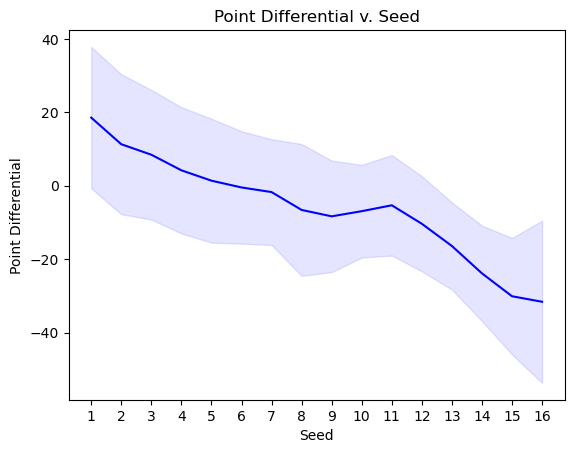

In [25]:
# Visualize how good of a metric seed is for predicting outcome
mu_seed = W_tourney_data.pivot_table(index = "T1_seed", values = "PointDiff", aggfunc = "mean").ffill()
sigma_seed =  W_tourney_data.pivot_table(index = "T1_seed", values = "PointDiff", aggfunc = "std").ffill()

bottom = list((mu_seed - sigma_seed)['PointDiff'])
top = list((mu_seed + sigma_seed)['PointDiff'])

plt.plot(mu_seed.index, mu_seed, 'b-')
plt.fill_between(mu_seed.index,bottom, top, color="b", alpha=0.1)
plt.xlabel('Seed')
plt.ylabel('Point Differential')
plt.xticks(list(range(1,17)))
plt.title("Point Differential v. Seed")

Text(0.5, 1.0, 'Point Differential v. Seed Differential')

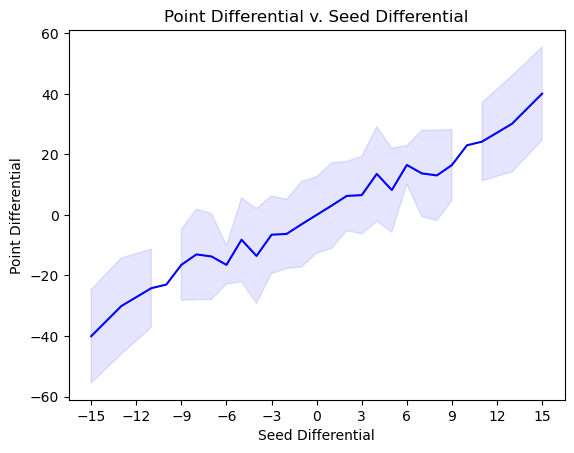

In [26]:
# Visualize how good of a metrics seed differential is for predicting outcome
mu_seed_diff = W_tourney_data.pivot_table(index = "seed_Diff", values = "PointDiff", aggfunc = "mean").ffill()
sigma_seed_diff =  W_tourney_data.pivot_table(index = "seed_Diff", values = "PointDiff", aggfunc = "std").ffill()

bottom = list((mu_seed_diff - sigma_seed_diff)['PointDiff'])
top = list((mu_seed_diff + sigma_seed_diff)['PointDiff'])

plt.plot(mu_seed_diff.index, mu_seed_diff, 'b-')
plt.fill_between(mu_seed_diff.index,bottom, top, color="b", alpha=0.1)
plt.xlabel('Seed Differential')
plt.ylabel('Point Differential')
plt.xticks(list(range(-15,16,3)))
plt.title("Point Differential v. Seed Differential")

In [27]:
def pagerank(M, d: float = 0.85):
    """PageRank Algorithm that treats teams as nodes, and outcome in their games as a link
    If Team a loses to Team b >= 1 time during the regular season, 
        This is an event where we demarcate power flow from Team a to Team b
        For Team A, we consider all its losses during the season
            For multiple losses against same team, take average point differential to aggregate
            Compute sum of all margins of loss and normalize each differential with that sum
            Set its column vector based on those calculations
                Team A loses to Team B by avg of 7.5 pts p game during regular season:
                    Entry at column A, Row B of 7.5 / total differential across all losses 
                    (accounting for normalization for losses to same team)
    
    Use the Power Calculation, applying fundamentals of linear algebra

    Parameters
    ----------
    M : numpy array
        adjacency matrix where M_i,j represents the link from 'j' to 'i', such that for all 'j'
        sum(i, M_i,j) = 1

    d : float, optional
        damping factor

    Returns
    -------
    numpy array
        a vector of ranks such that v_i is the i-th rank score (takes on values from  [0, 1]),
        the sum of the values in this array is 1.0

    """
    N = M.shape[1]
    w = np.ones(N) / N
    M_hat = d * M
    v = M_hat @ w + (1 - d) / N
    while np.linalg.norm(w - v) >= 1e-20:
        w = v
        v = M_hat @ w + (1 - d) / N
    return v

In [31]:
# helper function to get key attributes needed for PageRank Function: Winning Team, Losing Team, and their scores
def get_pagerank_info(year):
    return W_regular_season_results[W_regular_season_results["Season"] == year][["WTeamID", "WScore", "LTeamID", "LScore"]]

# list of years to process through
years = list(range(2010, 2026))
years.remove(2020)

# create an empty tample for storing PageRank information
W_pagerank = pd.DataFrame()

# for each year in the years list
for year_idx in tqdm(range(len(years))):

    # get the current year
    year = years[year_idx]

    # make a list of every team that played a game that year
    distinct_team_ids = []
    winner_id_list = get_pagerank_info(year)["WTeamID"].tolist()
    loser_id_list = get_pagerank_info(year)["LTeamID"].tolist()
    id_list = list(set(winner_id_list + loser_id_list))

    # make a helper map from TeamID to position in the distinct_team_id list
    idx_map = dict()
    for i in range(len(id_list)):
        idx_map[id_list[i]] = i

    # create an N x N matrix representing the flow of power in the PageRank Matrix
    N = len(id_list)
    M = np.zeros((N, N))

    # for each team in ID list, prepare a column representing its PageRank Vector
    for curr_team in id_list:

        # get that teams games for that year
        df = get_pagerank_info(year)

        # only factor in losses for each team, since that represents flow of power away from that team (what is stored in that column)
        loss_res = df[df["LTeamID"] == curr_team]

        # compute how much that team lost by and determine opponent team
        loss_res["Diff"] = loss_res["WScore"] - loss_res["LScore"]
        loss_res["Opp_Team"] = loss_res["WTeamID"]
        loss_res['Curr_Team'] = curr_team
        loss_res = loss_res.reset_index()

        # if a team lost to the same team multiple times, average the point differntial and drop the duplicate rows
        loss_res['Avg_Diff'] = loss_res.groupby(['Curr_Team', 'Opp_Team'])['Diff'].transform('mean')
        loss_res = loss_res.drop_duplicates(['Curr_Team', 'Opp_Team'])

        # determine the total point differential lost by across all losses this team had
        total_loss_diff = loss_res['Avg_Diff'].sum()

        # normalize the outgoing column vector based on that total point differential 
        loss_res['Norm_Diff'] = loss_res['Avg_Diff'] / total_loss_diff

        # only keep relevant rows
        loss_res = loss_res[['Curr_Team', 'Opp_Team', 'Norm_Diff']]

        # fill the appropriate positions in the matrix based on the team lost to and the power that flows to that team
        for index, row in loss_res.iterrows():
            c = idx_map[curr_team]
            r = idx_map[int(row['Opp_Team'])]
            M[r, c] += row['Norm_Diff']

    # compute a pagerank vector based on the matrix, and a damping factor parameter, experimentally chosen to be 0.1
    v = pagerank(M, 0.1) # between 0 and 1

    # create a list of tuples (i: position in id_list, x: strength as computed by pagerank)
    idx_power_list = []

    for i, x in enumerate(v):
        idx_power_list.append((i,x))

    # order the list by strongest to weakest teams
    idx_power_list.sort(key = lambda x: x[1], reverse = True)

    # append the results to the dataframe
    W_pagerank_year = pd.DataFrame({'PR_Power' : [x[1] for x in idx_power_list], 'TeamID' : [id_list[x[0]] for x in idx_power_list]})
    W_pagerank_year['Season'] = year

    W_pagerank = pd.concat([W_pagerank, W_pagerank_year])

100%|██████████| 15/15 [00:13<00:00,  1.13it/s]


In [32]:
W_pagerank

,PR_Power,TeamID,Season
0,0.005525,3163,2010
1,0.004230,3390,2010
2,0.004105,3401,2010
3,0.003917,3304,2010
4,0.003908,3181,2010
...,...,...,...
357,0.002497,3175,2025
358,0.002493,3354,2025
359,0.002493,3310,2025
360,0.002491,3421,2025


In [33]:
T1_PR = W_pagerank[["Season", "TeamID", "PR_Power"]].copy()
T2_PR = W_pagerank[["Season", "TeamID", "PR_Power"]].copy()

T1_PR.columns = ["Season", "T1_TeamID", "T1_PageRank"]
T2_PR.columns = ["Season", "T2_TeamID", "T2_PageRank"]

W_tourney_data_slice = W_tourney_data[["Season", "T1_TeamID", "T2_TeamID", "PointDiff", "win"]]

W_tourney_data_slice = pd.merge(W_tourney_data_slice, T1_PR, on=["Season", "T1_TeamID"], how = "left")
W_tourney_data_slice = pd.merge(W_tourney_data_slice, T2_PR, on=["Season", "T2_TeamID"], how = "left")

W_tourney_data_slice["PageRank_Diff"] = W_tourney_data_slice["T2_PageRank"] - W_tourney_data_slice["T1_PageRank"]
W_tourney_data = pd.merge(W_tourney_data, W_tourney_data_slice, on = ["Season", "T1_TeamID", "T2_TeamID", "PointDiff", "win"], how = "left")
W_tourney_data

,Season,T1_TeamID,T2_TeamID,PointDiff,win,T1_seed,T2_seed,seed_Diff,T1_PageRank,T2_PageRank,PageRank_Diff
0,2010,3124,3201,14.0,1,4,13,9,0.003661,0.003172,-0.000489
1,2010,3173,3395,1.0,1,8,9,1,0.003214,0.003274,0.000061
2,2010,3181,3214,35.0,1,2,15,13,0.003908,0.002984,-0.000924
3,2010,3199,3256,14.0,1,3,14,11,0.003641,0.003054,-0.000586
4,2010,3207,3265,20.0,1,5,12,7,0.003305,0.003123,-0.000182
...,...,...,...,...,...,...,...,...,...,...,...
1917,2025,3425,3163,-14.0,0,1,2,1,0.003870,0.004128,0.000258
1918,2025,3395,3400,-11.0,0,2,1,-1,0.003496,0.004201,0.000705
1919,2025,3417,3163,-34.0,0,1,2,1,0.003983,0.004128,0.000144
1920,2025,3400,3376,-17.0,0,1,1,0,0.004201,0.004442,0.000241


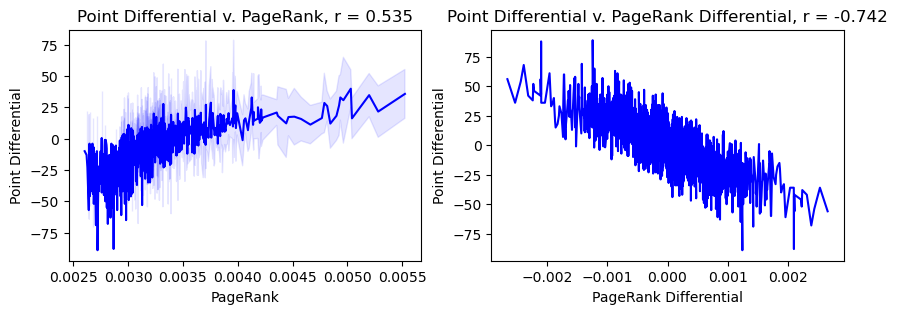

In [34]:
# Helper function that takes in a stat_name and start_year as input
# Plots and Displays Point Differential v. Raw Stat and Point Differential v. Stat Differential
def visualize_stat_correlation(stat_name, start_year = 2010):

    # Visualize how good of a metric the raw stat is for predicting outcome

    subset_tourney_data = W_tourney_data.loc[W_tourney_data["Season"] >= start_year].copy()

    corr_df = subset_tourney_data[["PointDiff", f"T1_{stat_name}"]].copy()
    r = corr_df.corr().iloc[0,1]

    mu_stat = subset_tourney_data.pivot_table(index = f"T1_{stat_name}", values = "PointDiff", aggfunc = "mean").ffill()
    sigma_stat = subset_tourney_data.pivot_table(index = f"T1_{stat_name}", values = "PointDiff", aggfunc = "std").ffill()

    bottom = list((mu_stat - sigma_stat)['PointDiff'])
    top = list((mu_stat + sigma_stat)['PointDiff'])

    fig, axs = plt.subplots(1, 2)
    fig.set_figheight(3)
    fig.set_figwidth(10)

    condensed_stat_name = stat_name if not "opponent" in stat_name else stat_name[:7] + stat_name[12:]

    axs[0].plot(mu_stat.index, mu_stat, 'b-')
    axs[0].fill_between(mu_stat.index,bottom, top, color="b", alpha=0.1)
    axs[0].set_xlabel(condensed_stat_name)
    axs[0].set_ylabel('Point Differential')
    axs[0].set_title(f"Point Differential v. {condensed_stat_name}, r = {r:.3f}")

    # Visualize how good of a metrics stat differential is for predicting outcome

    subset_tourney_data[f"{stat_name}_Diff"] = subset_tourney_data[f"T2_{stat_name}"] -  subset_tourney_data[f"T1_{stat_name}"]

    corr_diff_df = subset_tourney_data[["PointDiff", f"{stat_name}_Diff"]].copy()
    r_diff = corr_diff_df.corr().iloc[0,1]

    mu_seed_diff = subset_tourney_data.pivot_table(index = f"{stat_name}_Diff", values = "PointDiff", aggfunc = "mean").ffill()
    sigma_seed_diff =  subset_tourney_data.pivot_table(index = f"{stat_name}_Diff", values = "PointDiff", aggfunc = "std").ffill()

    bottom = list((mu_seed_diff - sigma_seed_diff)['PointDiff'])
    top = list((mu_seed_diff + sigma_seed_diff)['PointDiff'])

    axs[1].plot(mu_seed_diff.index, mu_seed_diff, 'b-')
    axs[1].fill_between(mu_seed_diff.index,bottom, top, color="b", alpha=0.1)
    axs[1].set_xlabel(f'{condensed_stat_name} Differential')
    axs[1].set_ylabel('Point Differential')
    axs[1].set_title(f"Point Differential v. {condensed_stat_name} Differential, r = {r_diff:.3f}")

    plt.show()

visualize_stat_correlation("PageRank")

In [35]:
# list which stats we want to aggregate acros the season for each team 
#   - calculate all interesting features
box_score_stats = [
    "T1_Score", "T1_FGM", "T1_FGA", "T1_FGM3", "T1_FGA3", "T1_FTM", "T1_FTA",
    "T1_OR", "T1_DR", "T1_Ast", "T1_TO", "T1_Stl", "T1_Blk", "T1_PF",
    "T2_Score", "T2_FGM", "T2_FGA", "T2_FGM3", "T2_FGA3", "T2_FTM", "T2_FTA",
    "T2_OR", "T2_DR", "T2_Ast", "T2_TO", "T2_Stl", "T2_Blk", "T2_PF",
    "PointDiff"
]

In [36]:
# aggregate the average statistics for every team across the season and concatenate the corresponding
# columns on the tournament matchup data
season_stats = W_reg_data.groupby(["Season", "T1_TeamID"])[box_score_stats].agg("mean").reset_index()

season_stats_T1 = season_stats.copy()
season_stats_T1.columns = ["T1_avg_" + x.replace("T1_", "").replace("T2_", "opponent_") for x in list(season_stats_T1.columns)]
season_stats_T1 = season_stats_T1.rename({"T1_avg_Season" : "Season", "T1_avg_TeamID" : "T1_TeamID"}, axis = 1)

season_stats_T2 = season_stats.copy()
season_stats_T2.columns = ["T2_avg_" + x.replace("T1_", "").replace("T2_", "opponent_") for x in list(season_stats_T2.columns)]
season_stats_T2 = season_stats_T2.rename({"T2_avg_Season" : "Season", "T2_avg_TeamID" : "T2_TeamID"}, axis = 1)

W_tourney_data = pd.merge(W_tourney_data, season_stats_T1, on = ["Season", "T1_TeamID"], how = "left")
W_tourney_data = pd.merge(W_tourney_data, season_stats_T2, on = ["Season", "T2_TeamID"], how = "left")
W_tourney_data

,Season,T1_TeamID,T2_TeamID,PointDiff,win,T1_seed,T2_seed,seed_Diff,T1_PageRank,T2_PageRank,PageRank_Diff,T1_avg_Score,T1_avg_FGM,T1_avg_FGA,T1_avg_FGM3,T1_avg_FGA3,T1_avg_FTM,T1_avg_FTA,T1_avg_OR,T1_avg_DR,T1_avg_Ast,T1_avg_TO,T1_avg_Stl,T1_avg_Blk,T1_avg_PF,T1_avg_opponent_Score,T1_avg_opponent_FGM,T1_avg_opponent_FGA,T1_avg_opponent_FGM3,T1_avg_opponent_FGA3,T1_avg_opponent_FTM,T1_avg_opponent_FTA,T1_avg_opponent_OR,T1_avg_opponent_DR,T1_avg_opponent_Ast,T1_avg_opponent_TO,T1_avg_opponent_Stl,T1_avg_opponent_Blk,T1_avg_opponent_PF,T1_avg_PointDiff,T2_avg_Score,T2_avg_FGM,T2_avg_FGA,T2_avg_FGM3,T2_avg_FGA3,T2_avg_FTM,T2_avg_FTA,T2_avg_OR,T2_avg_DR,T2_avg_Ast,T2_avg_TO,T2_avg_Stl,T2_avg_Blk,T2_avg_PF,T2_avg_opponent_Score,T2_avg_opponent_FGM,T2_avg_opponent_FGA,T2_avg_opponent_FGM3,T2_avg_opponent_FGA3,T2_avg_opponent_FTM,T2_avg_opponent_FTA,T2_avg_opponent_OR,T2_avg_opponent_DR,T2_avg_opponent_Ast,T2_avg_opponent_TO,T2_avg_opponent_Stl,T2_avg_opponent_Blk,T2_avg_opponent_PF,T2_avg_PointDiff
0,2010,3124,3201,14.0,1,4,13,9,0.003661,0.003172,-0.000489,71.885417,26.006944,56.104167,2.461806,8.611111,17.409722,23.961806,12.159722,30.944444,14.645833,16.836806,6.951389,7.211806,14.090278,56.628472,21.034722,62.350694,5.517361,19.895833,9.041667,13.156250,12.618056,21.656250,9.461806,15.673611,6.628472,1.871528,19.204861,15.256944,73.181818,25.760943,61.380471,8.801347,24.784512,12.858586,18.127946,13.838384,24.464646,14.612795,15.558923,10.373737,2.599327,16.309764,60.313131,22.848485,56.451178,4.134680,13.794613,10.481481,16.202020,12.175084,24.727273,11.808081,19.828283,6.740741,2.592593,16.144781,12.868687
1,2010,3173,3395,1.0,1,8,9,1,0.003214,0.003274,0.000061,69.849573,25.528205,60.747009,5.417949,17.310256,13.375214,19.143590,14.580342,27.637607,14.217094,16.688034,7.683761,4.002564,16.416239,58.590598,21.231624,57.737607,5.332479,16.570085,10.794872,16.391453,11.866667,23.457265,11.471795,18.195726,7.504274,4.320513,17.997436,11.258974,71.133333,25.422222,61.411111,6.800000,19.000000,13.488889,18.033333,13.377778,25.533333,15.455556,15.866667,9.655556,3.577778,16.000000,59.233333,21.444444,58.933333,5.611111,19.944444,10.733333,16.033333,14.711111,24.966667,13.233333,20.311111,8.388889,3.444444,16.311111,11.900000
2,2010,3181,3214,35.0,1,2,15,13,0.003908,0.002984,-0.000924,71.593750,26.843750,63.750000,4.562500,14.468750,13.343750,20.156250,17.718750,25.593750,14.250000,17.906250,13.375000,5.281250,17.687500,55.062500,18.843750,53.593750,5.312500,16.593750,12.062500,18.125000,12.500000,21.968750,11.375000,23.218750,7.531250,3.281250,17.875000,16.531250,62.600000,22.111111,59.803704,4.892593,16.037037,13.485185,18.844444,14.874074,22.588889,11.570370,15.496296,10.048148,2.214815,18.785185,54.914815,18.914815,49.722222,2.859259,10.303704,14.225926,21.944444,12.581481,26.003704,8.685185,22.040741,6.614815,2.259259,16.633333,7.685185
3,2010,3199,3256,14.0,1,3,14,11,0.003641,0.003054,-0.000586,74.466667,26.400000,59.200000,6.100000,16.100000,15.566667,21.800000,14.400000,27.266667,15.333333,19.033333,8.833333,4.033333,17.133333,60.100000,21.333333,59.566667,5.300000,18.433333,12.133333,17.466667,13.400000,21.166667,12.233333,19.200000,8.200000,2.133333,18.933333,14.366667,73.713262,26.964158,62.064516,3.906810,12.351254,15.878136,23.146953,14.720430,29.526882,14.405018,16.974910,7.053763,3.716846,15.856631,63.777778,23.720430,63.605735,4.752688,17.204301,11.584229,17.824373,13.612903,24.240143,10.677419,17.304659,8.143369,4.218638,19.519713,9.935484
4,2010,3207,3265,20.0,1,5,12,7,0.003305,0.003123,-0.000182,67.352593,23.628148,59.572593,6.269630,19.824444,13.826667,19.279259,15.591111,19.211852,15.737778,16.104444,13.237778,2.579259,17.773333,57.646667,19.526667,48.274074,5.357778,18.611852,13.235556,18.404444,11.922963,22.569630,13.128889,24.331111,7.866667,3.181481,16.752593,9.705926,67.666667,23.232323,55.252525,6.484848,18.882155,14.717172,18.404040,10.430976,26.104377,14.346801,13.393939,7.838384,4.471380,13.868687,57.37037

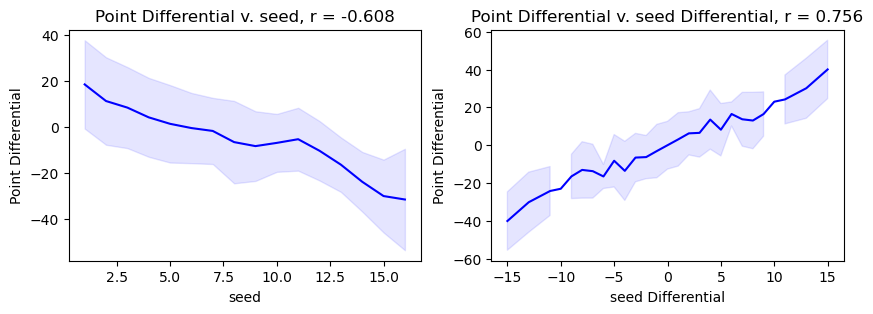

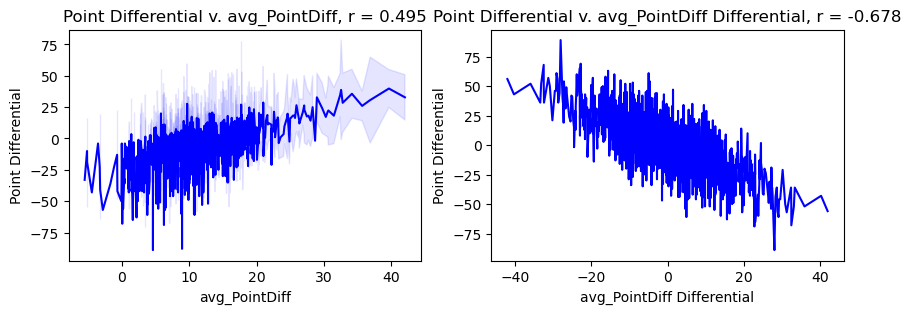

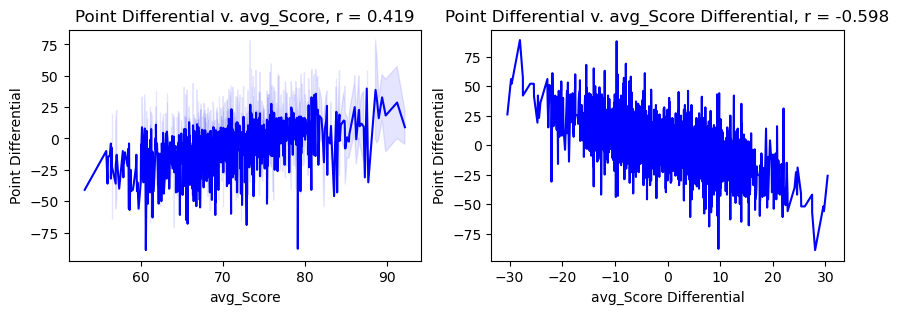

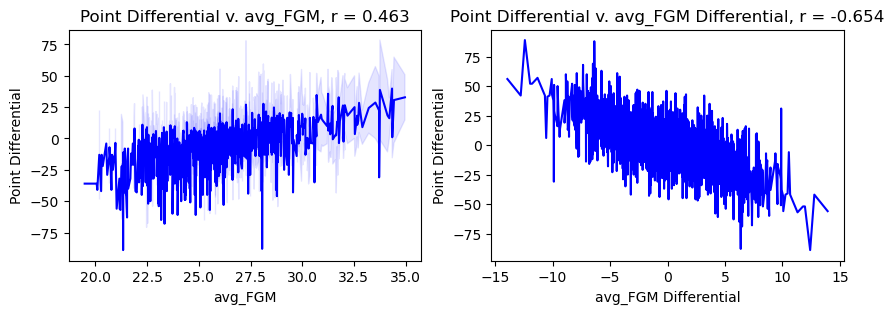

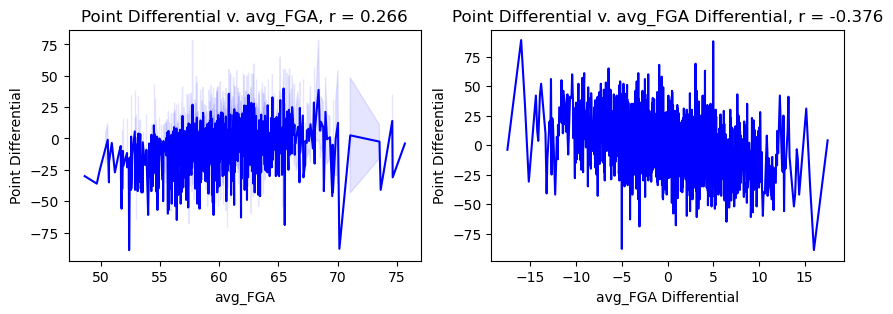

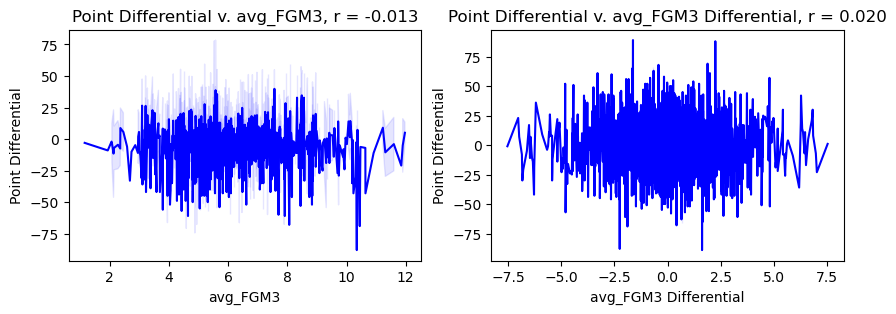

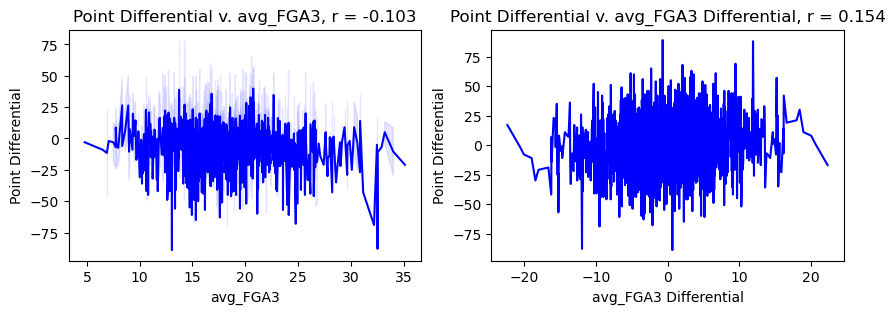

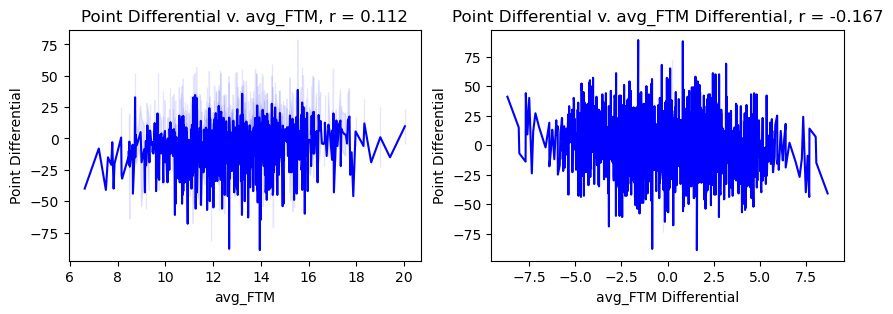

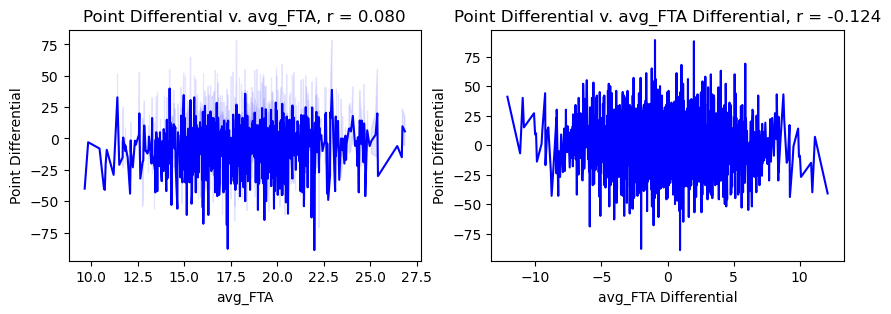

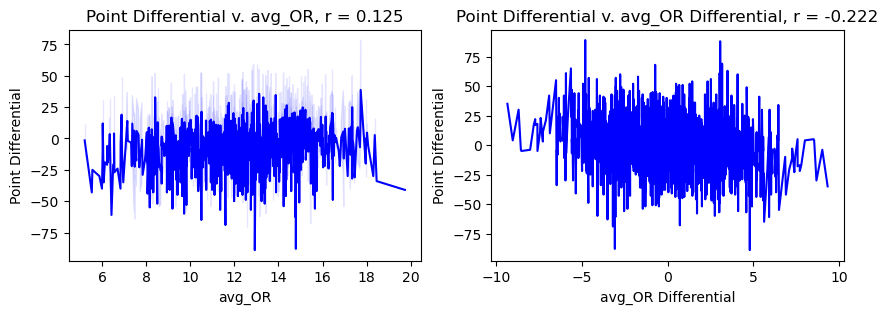

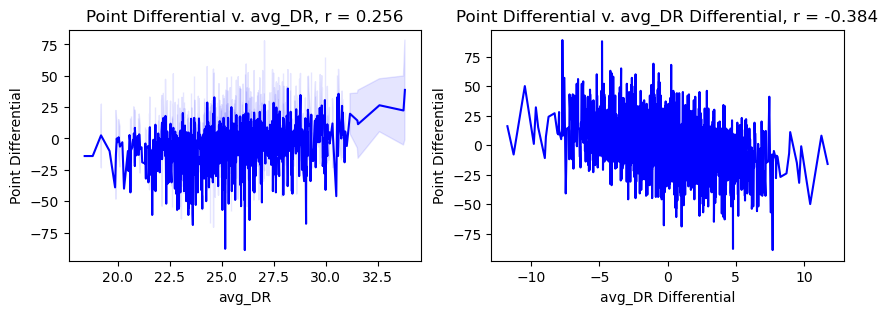

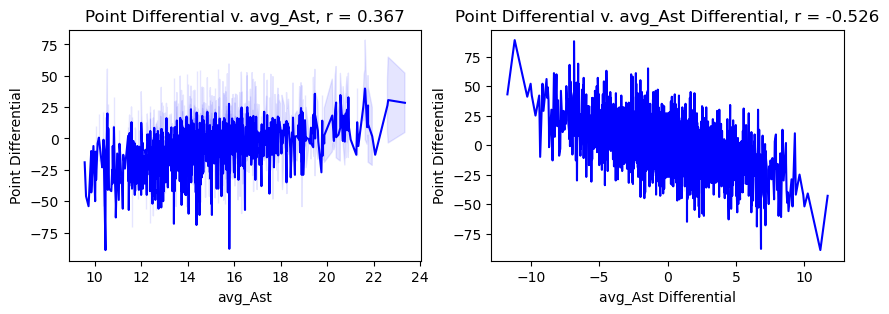

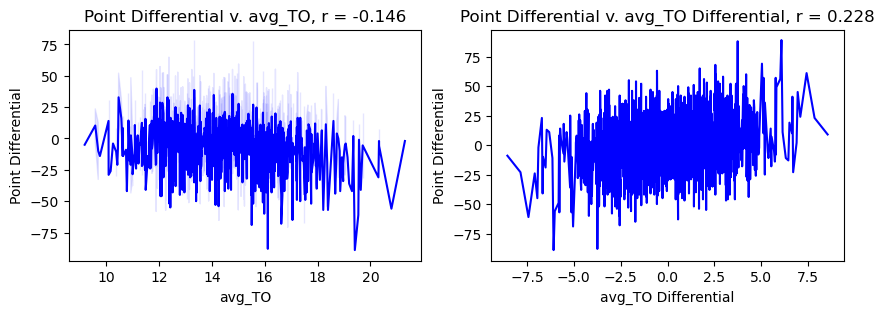

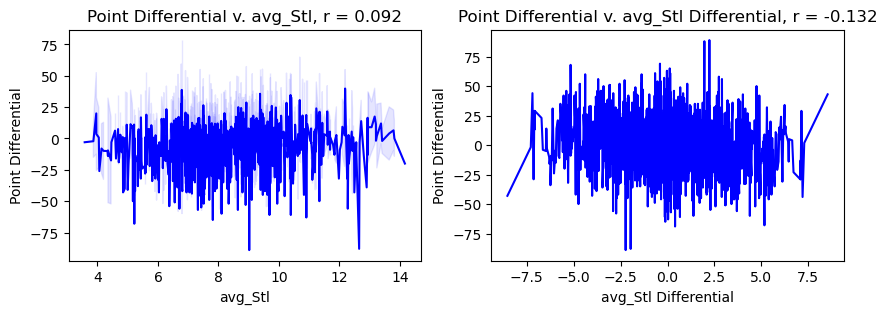

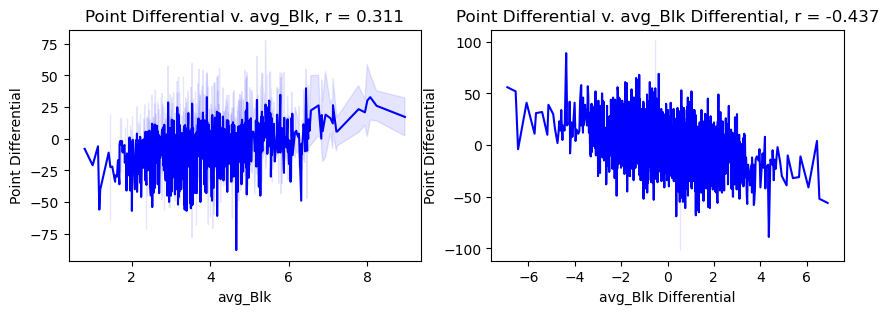

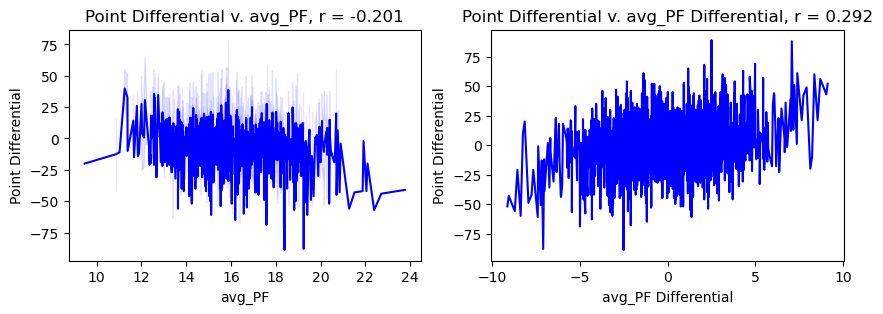

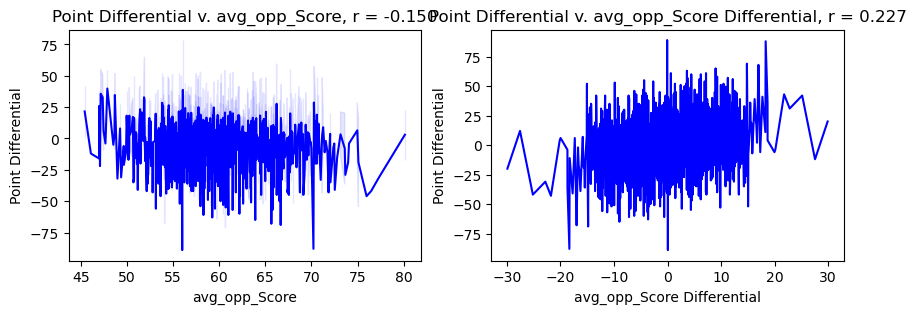

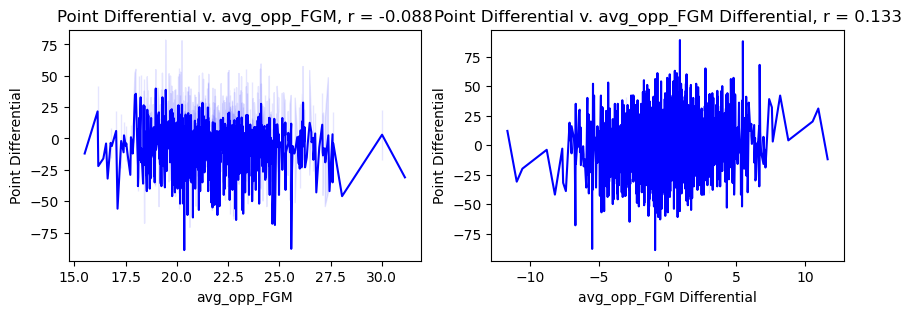

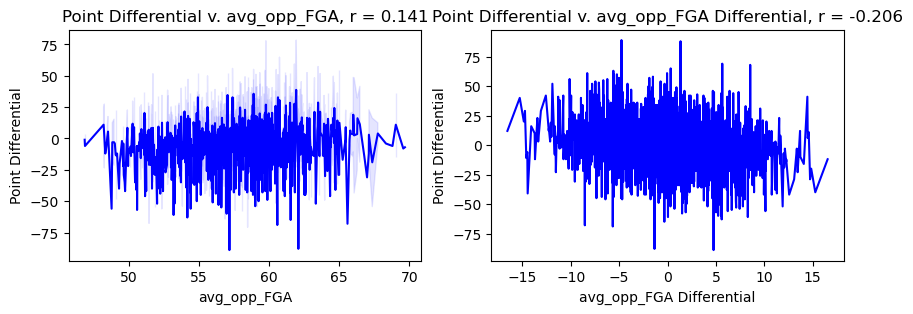

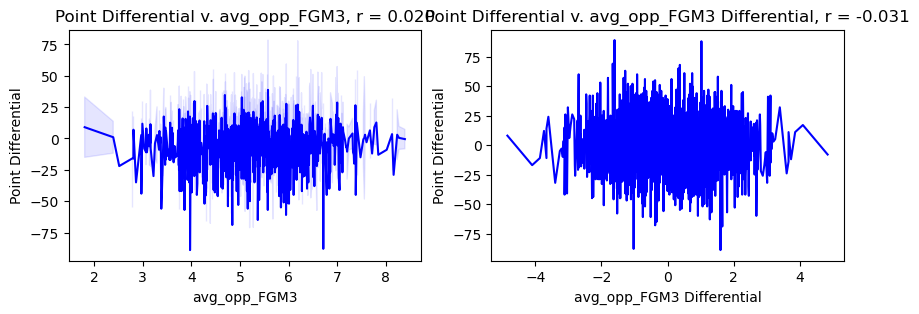

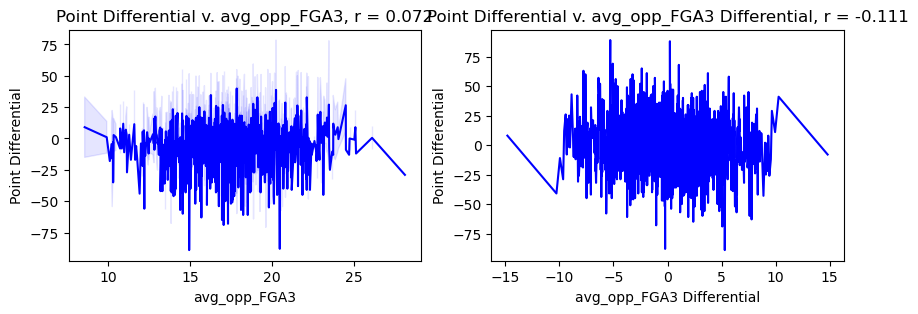

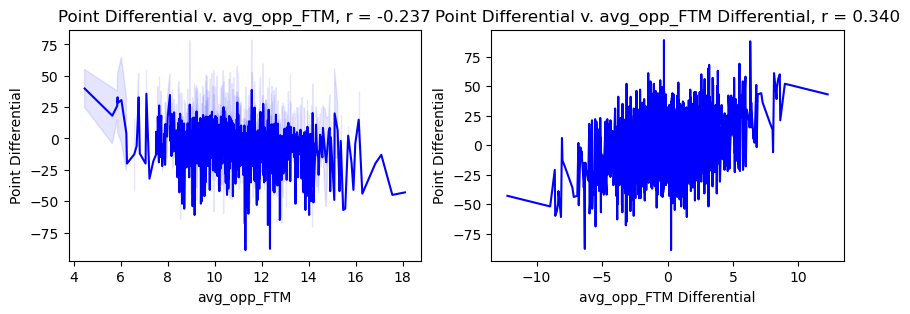

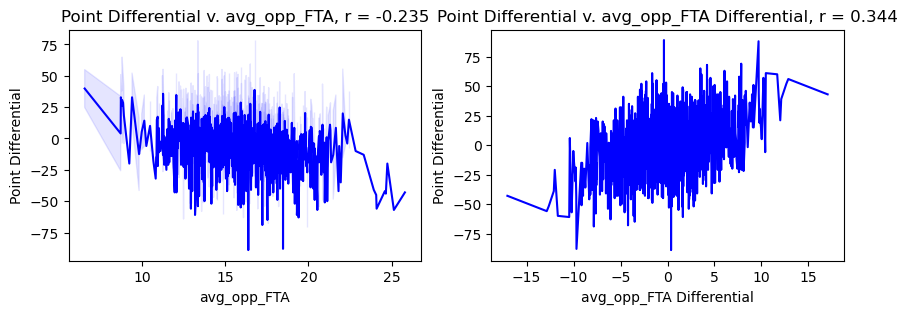

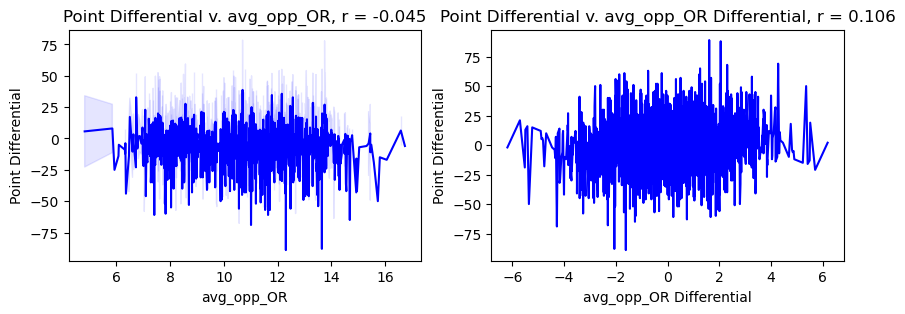

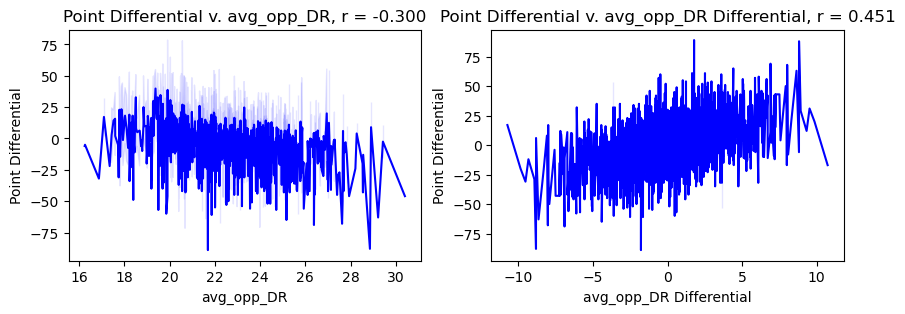

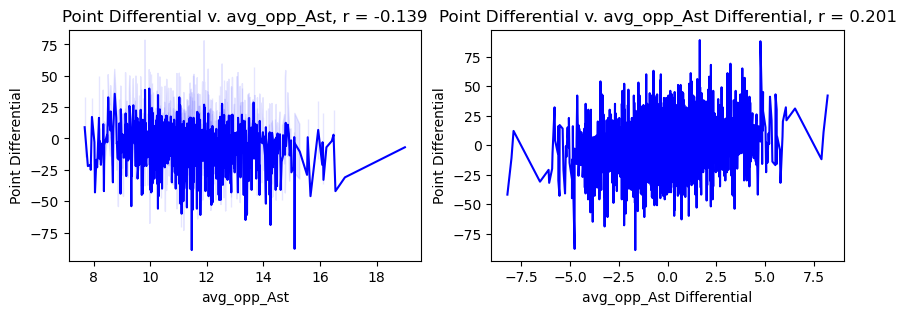

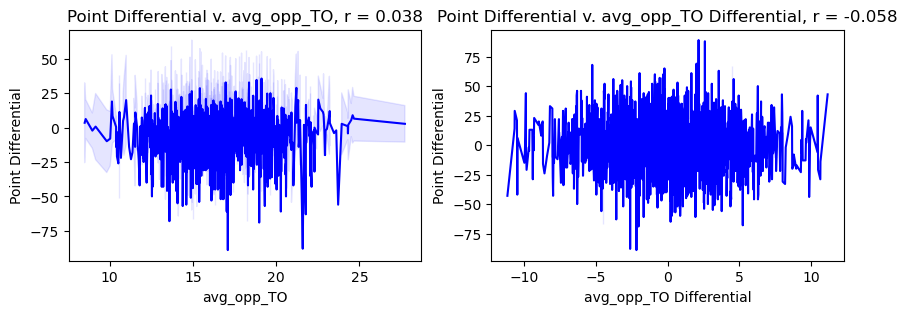

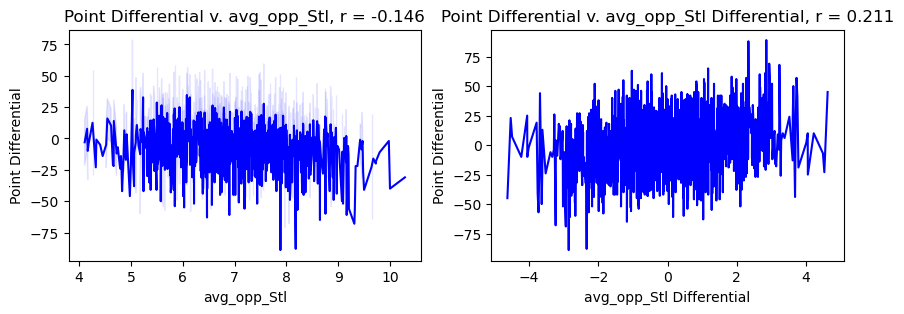

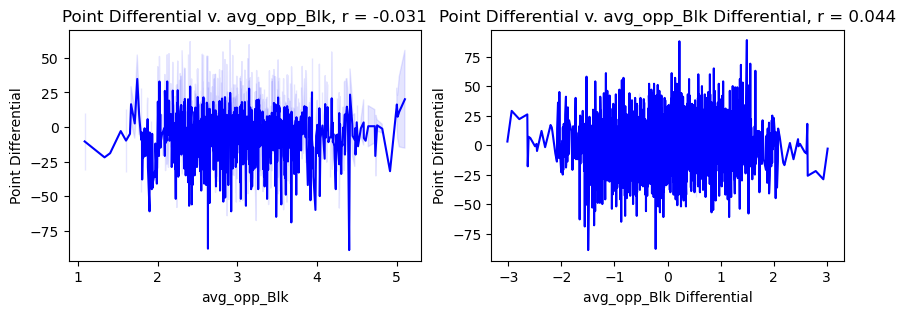

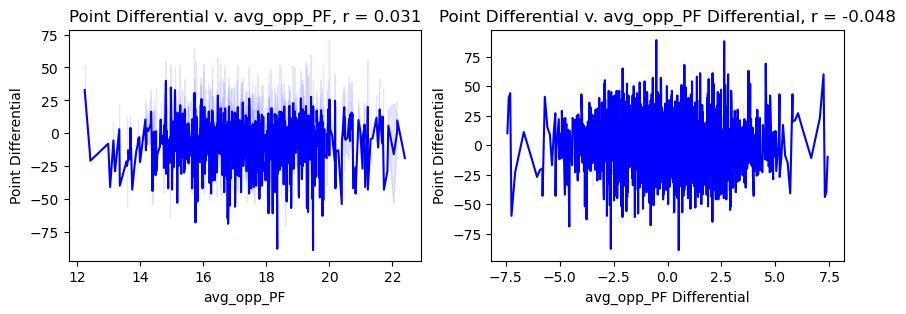

In [37]:
# select a set of stats and view how correlated they are with tournament point differential
my_stats = ["seed", "avg_PointDiff", 'avg_Score', "avg_FGM", "avg_FGA", "avg_FGM3", "avg_FGA3", 
            "avg_FTM", "avg_FTA", 'avg_OR', "avg_DR", "avg_Ast", "avg_TO", "avg_Stl", 
            "avg_Blk", "avg_PF"]

opponent_stats = [stat[:4] + "opponent_" + stat[4:] for stat in my_stats[2:]]

for statistic in my_stats:
    visualize_stat_correlation(statistic)

for statistic in opponent_stats:
    visualize_stat_correlation(statistic)

In [ ]:
# Helper function that takes in a stat_name and start_year as input
# Plots and Displays Point Differential v. Raw Stat and Point Differential v. Stat Differential
def visualize_stat_correlation_over_time(stat_list):

    for stat_name in stat_list:

        years = list(range(2010, 2026))
        years.remove(2020)

        r_list = []

        for year in years:

            subset_tourney_data = W_tourney_data.loc[W_tourney_data["Season"] == year].copy()

            subset_tourney_data[f"{stat_name}_Diff"] = subset_tourney_data[f"T2_{stat_name}"] -  subset_tourney_data[f"T1_{stat_name}"]

            corr_diff_df = subset_tourney_data[["PointDiff", f"{stat_name}_Diff"]].copy()
            r_diff = corr_diff_df.corr().iloc[0,1]

            r_list.append(abs(r_diff))

        plt.plot(years, r_list, label = stat_name)
    
    plt.title(f"PointDiff v. Stat_Diff |Correlation| Over Time")
    plt.ylabel("r")
    plt.xlabel("Year")
    plt.legend(bbox_to_anchor = (1.1, 0.75))
    plt.show()


score_stats =  ["avg_PointDiff", 'avg_Score', "avg_FGM", "avg_FGA", "avg_FGM3", "avg_FGA3", 
            "avg_FTM", "avg_FTA"]

non_score_stats = ['avg_OR', "avg_DR", "avg_Ast", "avg_TO", "avg_Stl", 
            "avg_Blk", "avg_PF"]

rank_stats = ['seed', 'PageRank']

opp_score_stats = [stat[:4] + "opponent_" + stat[4:] for stat in score_stats[1:]]
opp_non_score_stats = [stat[:4] + "opponent_" + stat[4:] for stat in non_score_stats]

visualize_stat_correlation_over_time(score_stats)
visualize_stat_correlation_over_time(non_score_stats)
visualize_stat_correlation_over_time(opp_score_stats)
visualize_stat_correlation_over_time(opp_non_score_stats)
visualize_stat_correlation_over_time(rank_stats)